In [ ]:
# Instalación de dependencias
!pip install langchain langchain-openai langchain-community langchain-chroma
!pip install langchain-text-splitters chromadb pypdf requests
!pip install sentence-transformers langchain-huggingface
!pip install transformers bitsandbytes accelerate

# RAG: Retrieval-Augmented Generation con LangChain

## ¿Qué problema resuelve RAG?

Los LLMs  son herramientas muy potentes para entender y generar texto. Sin embargo, tienen una limitación fundamental: **su *conocimiento* está limitado** a los datos existentes en los documentos utilizados para su entrenamiento. Tampoco **tienen acceso a información privada o específica** que no formó parte de eso datos de entrenamiento

Por ejemplo, si le preguntamos a un LLM:

> *¿Quién es Luis Gasco?*

Lo más probable es que no sepa quién es, que invente información incorrecta (*alucinaciones*), o que el modelo pregunte sobre más información para dar algo de información sobre esa persona. Esto supone un grave problema cuando queremos usar estos modelos para razonar sobre **documentos propios**, **bases de conocimiento privadas** o **información reciente**.

**RAG (Retrieval-Augmented Generation)** es una técnica que resuelve este problema combinando dos capacidades:

1. **Recuperación de información** (*Retrieval*): buscar los fragmentos de texto más relevantes de una base de conocimiento privada.
2. **Generación de respuestas** (*Generation*): usar el LLM para generar una respuesta basándose en esos fragmentos recuperados como contexto.

De esta forma, el modelo no necesita "memorizar" toda la información, sino que puede **consultarla en el momento de responder**.

## Arquitectura de un sistema RAG

El siguiente diagrama resume el funcionamiento de un pipeline RAG de principio a fin:



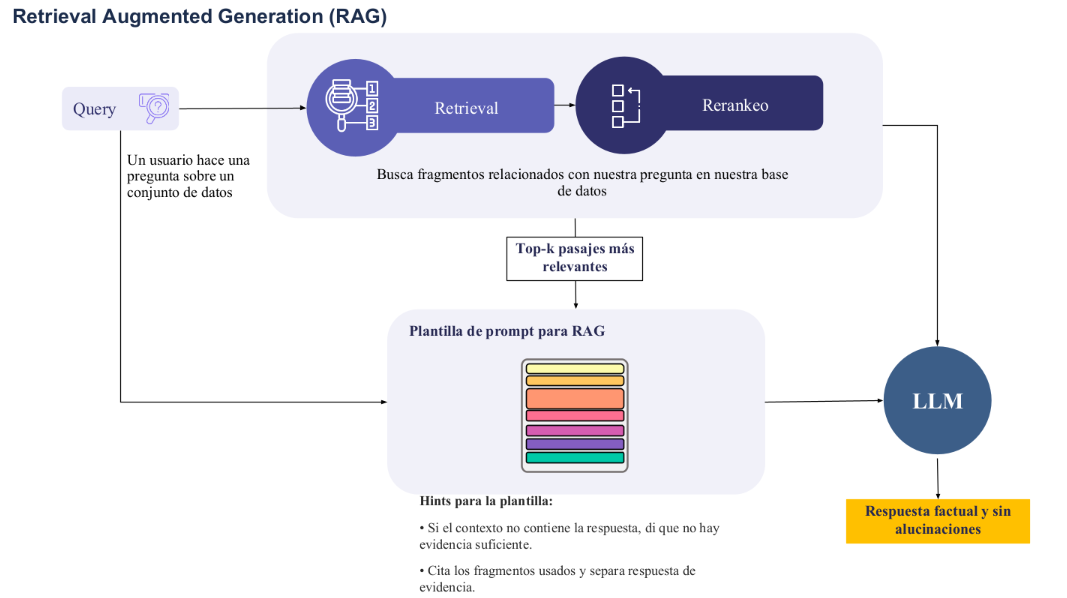



Siguiendo el flujo del diagrama:

1. **Query**: El usuario formula una pregunta sobre un conjunto de datos que el modelo no conoce de antemano.

2. **Retrieval**: El sistema busca en la base de datos vectorial los fragmentos (*chunks*) del documento más relacionados semánticamente con la pregunta.

3. **Rerankeo**: Los fragmentos recuperados se reordenan para priorizar los más relevantes (*top-k pasajes más relevantes*). En este notebook implementamos la versión sin rerankeo (enfoque *naive*) para centrarnos en una arquitectura básica.

4. **Plantilla de prompt para RAG**: La pregunta del usuario y los pasajes recuperados se combinan en un prompt estructurado que se envía al LLM. La plantilla incluye dos indicaciones clave:
   - *Si el contexto no contiene la respuesta, di que no hay evidencia suficiente.*
   - *Cita los fragmentos usados y separa respuesta de evidencia.*

5. **LLM**: El modelo de lenguaje genera la respuesta basándose exclusivamente en el contexto proporcionado, sin inventar información.

6. **Respuesta factual y sin alucinaciones**: El resultado es una respuesta fundamentada en el documento original, con referencias a los fragmentos concretos que la sustentan.

En este notebook implementaremos este pipeline completo utilizando [**LangChain**](https://python.langchain.com/), un framework que facilita la creación de aplicaciones basadas en modelos de lenguaje, permitiendo la unión de todos estos componentes de forma sencilla

## Librerías utilizadas en este notebook



### 🔗 LangChain

[**LangChain**](https://python.langchain.com/) se ha convertido en el **estándar de facto** para construir aplicaciones basadas en modelos de lenguaje. Su filosofía es proporcionar **abstracciones componibles** que permiten conectar de forma sencilla todos los elementos de un pipeline de IA: loaders de datos, splitters, embeddings, bases de datos vectoriales, LLMs y cadenas de procesamiento.

Sus principales ventajas para este tipo de proyectos son:

- **Interfaz unificada para múltiples modelos**: La librería permite trabajar con conectores para modelos propietarios (OpenAI, Anthropic…) como con modelos de código abierto descargados desde [HuggingFace](https://huggingface.co/).
- **Componentes reutilizables e intercambiables**: cada pieza es independiente y configurable sin tocar el resto del pipeline.

### Componentes de LangChain utilizados

| Componente | Clase LangChain | Función en el pipeline |
|---|---|---|
| **Document Loader** | `PyPDFLoader` | Carga y extrae texto de un PDF página a página |
| **Text Splitter** | `RecursiveCharacterTextSplitter` | Divide el texto en chunks con overlap. Existen otros splitters más inteligentes que no se utilizan en este ejercicio, como `SemanticChunker` que considera la semántica del texto. |
| **Embeddings closed-source** | `OpenAIEmbeddings` | Vectoriza los chunks en vectores con información semántica vía la API de OpenAI |
| **Embeddings open-source** | `HuggingFaceEmbeddings` | Vectoriza con `sentence-transformers` en local |
| **Vector Store** | `Chroma` | Base de datos vectorial para búsqueda semántica. Similar al Faiss. |
| **LLM closed-source** | `ChatOpenAI` | Generación vía API de OpenAI |
| **LLM open-source** | `HuggingFacePipeline` | Generación con modelos LLM locales. En este caso cargaremos un modelo Qwen cuantizado ejecutándose en local |
| **Prompt** | `ChatPromptTemplate` / `PromptTemplate` | Estructura el prompt con contexto + pregunta |
| **Orquestación** | `RunnableParallel` + LCEL (`\|`) | Conecta recuperación, generación y extracción de fuentes |

### Variantes

En este notebook se presentan dos variantes del sistema RAG. Por una parte se llevará a cabo una implementación con modelos closed-source (OpenAI) y por otra con modelos open-source (HuggingFace).

El uso de OpenAI requiere de tener la cuenta API de OpenAI configurada y acceso a una clave API. Hay que tener en cuentas que en este caso, los datos salen del servidor local y si se trabajara con datos privados (por ejemplo sanitarios o de clientes), se deberían revisar las claúsulas de privacidad de datos y de envío de información a sistemas externos.

## 🔹 Documento de ejemplo

A lo largo de este notebook utilizaremos como base de conocimiento mi CV en pdf, descargado en mi página web.

El objetivo es construir un sistema capaz de responder preguntas sobre el contenido de ese CV, demostrando que:

- **Sin RAG**: el LLM no sabe quién soy, ni tiene detalles sobre mi formación y experiencia profesional.
- **Con RAG**: el LLM puede responder con precisión usando el CV como contexto.

## Imports

In [5]:
import os
import requests
import numpy as np

## 1. Descarga y carga del PDF

El primer paso es obtener el documento que vamos a indexar. En este caso descargamos el CV de Luis Gasco directamente desde su web usando la librería `requests`.

In [6]:
# Descarga del PDF
url = "https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf"
response = requests.get(url)

with open("cv_luisgasco.pdf", "wb") as f:
    f.write(response.content)

print(f"✅ PDF descargado correctamente ({len(response.content) / 1024:.1f} KB)")

✅ PDF descargado correctamente (156.5 KB)


Una vez descargado, utilizamos `PyPDFLoader` de LangChain para cargarlo. Este loader extrae el texto página por página y genera una lista de objetos `Document`, donde cada uno contiene:

- `page_content`: el texto de esa página.
- `metadata`: información como el número de página y la ruta del archivo.

In [7]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("cv_luisgasco.pdf")
documents = loader.load()

print(f"📄 Número de páginas cargadas: {len(documents)}")
print()
print("--- Primeras líneas de la primera página ---")
print(documents[0].page_content[:600])
print()
print(f"Metadatos: {documents[0].metadata}")

📄 Número de páginas cargadas: 5

--- Primeras líneas de la primera página ---
Luis Gascó
INTERDiSCiPLiNARY RESEARCHER
Madrid/Barcelona, Spain
 +34 662 25 95 70 |  luisgascosanchez@gmail.com |  luisgasco.es |  luisgasco |  luisgascosanchez
Professional Summary
+8 years of experience analyzing urban and health data, and +5 years in the use of language technologies to extract information
contained in texts. During my career, I have applied advanced machine learning, NLP and statistical technologies in the field of
healthcare, environmental studies, and urban management to detect and solve problems in each domain. I am an enthusiast of
using cutting‑edge technologies t

Metadatos: {'producer': 'MiKTeX-dvipdfmx (20230429)', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-09-13T11:55:16+02:00', 'source': 'cv_luisgasco.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}


## 2. División en chunks (Text Splitting)

Los modelos de embeddings (y los LLMs en el momento de la generación) tienen un **límite en la cantidad de texto que pueden procesar** de una vez. Por eso, en lugar de indexar el PDF completo como un único bloque, lo dividimos en fragmentos más pequeños llamados **chunks**.

Una buena estrategia de chunking debe garantizar que:

1. Cada chunk sea **semánticamente coherente** (no cortar frases a mitad).
2. Los chunks sean lo suficientemente **grandes** para tener contexto útil.
3. Los chunks sean lo suficientemente **pequeños** para ser precisos.
4. Haya cierto **solapamiento** (*overlap*) entre chunks consecutivos para no perder información en los bordes.

### 🔹 RecursiveCharacterTextSplitter

El método más habitual (y el que usaremos aquí) es el `RecursiveCharacterTextSplitter`. Intenta dividir el texto respetando separadores naturales en orden de preferencia: primero párrafos (`\n\n`), luego saltos de línea (`\n`), luego espacios (` `), y finalmente carácter a carácter si es necesario.

Los parámetros clave son:

- `chunk_size`: número máximo de caracteres por chunk.
- `chunk_overlap`: número de caracteres que se solapan entre chunks consecutivos.

> **Nota**: en la práctica, el valor óptimo de estos parámetros depende del tipo de documento y del modelo de embeddings. 400 caracteres con 100 de overlap es un punto de partida razonable (*naive*) para documentos como un CV. En una aplicación real se podrían aplicar segmentadores específicos para dividir el CV en secciones, y posteriormente aplicar chunkers semánticos.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

chunks = text_splitter.split_documents(documents)
print(f"✅ Número de chunks generados: {len(chunks)}")

✅ Número de chunks generados: 62


### Verificación de la calidad de los chunks

Antes de continuar, es importante inspeccionar los chunks generados para asegurarnos de que el texto se ha dividido correctamente y que cada fragmento tiene sentido semánticamente. Inspeccionamos los primeros chunks y calculamos estadísticas básicas de longitud.

In [9]:
# Inspeccionamos los primeros 5 chunks
print("=" * 60)
for i, chunk in enumerate(chunks[:5]):
    print(f"--- Chunk {i+1} (pág. {chunk.metadata.get('page', '?')}) ---")
    print(chunk.page_content)
    print()

--- Chunk 1 (pág. 0) ---
Luis Gascó
INTERDiSCiPLiNARY RESEARCHER
Madrid/Barcelona, Spain
 +34 662 25 95 70 |  luisgascosanchez@gmail.com |  luisgasco.es |  luisgasco |  luisgascosanchez
Professional Summary
+8 years of experience analyzing urban and health data, and +5 years in the use of language technologies to extract information

--- Chunk 2 (pág. 0) ---
contained in texts. During my career, I have applied advanced machine learning, NLP and statistical technologies in the field of
healthcare, environmental studies, and urban management to detect and solve problems in each domain. I am an enthusiast of
using cutting‑edge technologies to solve real‑world problems, with a background in engineering complemented with knowledge

--- Chunk 3 (pág. 0) ---
of entrepreneurship, technology transfer and project management obtained in the framework of the EIT Digital Doctoral School.
Throughout my career I have had the opportunity to work on international projects in countries such as Fran

In [10]:
# Estadísticas de longitud de los chunks
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

print("📊 Estadísticas de longitud de los chunks:")
print(f"   Número total de chunks : {len(chunk_lengths)}")
print(f"   Longitud media         : {np.mean(chunk_lengths):.0f} caracteres")
print(f"   Desviación típica      : {np.std(chunk_lengths):.0f} caracteres")
print(f"   Longitud mínima        : {min(chunk_lengths)} caracteres")
print(f"   Longitud máxima        : {max(chunk_lengths)} caracteres")

# Identificamos chunks muy cortos (posibles ruido o artefactos del PDF)
short_chunks = [c for c in chunks if len(c.page_content) < 50]
print(f"\n⚠️  Chunks con menos de 50 caracteres: {len(short_chunks)}")
for c in short_chunks:
    print(f"   → '{c.page_content}'")

📊 Estadísticas de longitud de los chunks:
   Número total de chunks : 62
   Longitud media         : 328 caracteres
   Desviación típica      : 67 caracteres
   Longitud mínima        : 86 caracteres
   Longitud máxima        : 398 caracteres

⚠️  Chunks con menos de 50 caracteres: 0


A partir de esta inspección podemos observar:

- La mayoría de los chunks tienen una longitud cercana a `chunk_size` (500 caracteres).
- Algunos chunks son más cortos porque corresponden a párrafos cortos (p.ej., encabezados o líneas sueltas del CV).
- Los chunks cortos pueden introducir ruido en la recuperación. En un sistema de producción se filtrarían o se fusionarían con el chunk siguiente.

> **Reflexión**: en un CV, secciones como *Publications* pueden generar muchos chunks pequeños (una publicación por chunk), lo que puede dificultar preguntas de tipo *"¿Cuántas publicaciones tiene?"*. Estrategias más avanzadas como **semantic chunking** o **parent-document retriever** abordan este problema.

---

## 3. RAG con OpenAI

En esta sección construiremos el sistema RAG utilizando los modelos de OpenAI tanto para los **embeddings** como para la **generación**.

> ⚠️ **Requisitos**:
> - Una cuenta en [platform.openai.com](https://platform.openai.com) con créditos disponibles.
> - La **API key** de OpenAI guardada como secreto en Google Colab (menú lateral → 🔑 *Secrets* → añadir `OPENAI_API_KEY`).

In [11]:
# 👉 Introduce tu clave de OpenAI (se guarda solo en la sesión actual)
import os, getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("🔑 OpenAI API key: ")
print("✅ Clave configurada.")


🔑 OpenAI API key: ··········
✅ Clave configurada.


### 3.1. Sin RAG — ¿Qué sabe GPT sobre Luis Gasco?

Antes de construir el sistema RAG, vamos a comprobar qué responde GPT-3.5 cuando le preguntamos directamente por Luis Gasco, **sin proporcionarle ningún contexto adicional**.

Esto nos servirá como **línea base** para ver la mejora que aporta RAG.

In [12]:
from langchain_openai import ChatOpenAI

# Iniciamos el modelo sin RAG
llm_openai = ChatOpenAI(model="gpt-5.4-nano", temperature=0)

respuesta_sin_rag = llm_openai.invoke("¿Quién es Luis Gasco?")
print("🤖 Respuesta del modelo SIN RAG:")
print("-" * 50)
print(respuesta_sin_rag.content)

🤖 Respuesta del modelo SIN RAG:
--------------------------------------------------
No tengo suficiente contexto para identificar a cuál **Luis Gascó** te refieres, porque puede haber varias personas con ese nombre (por ejemplo, en distintos países o ámbitos).

¿Me dices **de qué país** o **a qué se dedica** (o si lo viste en una noticia, empresa, deporte, etc.)? Con un poco más de información te puedo identificar mejor.


Como se puede observar, el modelo **no sabe quién es Luis Gasco (yo)**. Probablemente si que tenga información sobre algún Luis Gascó en los pesos de su modelo, pero no suficientemente clara como para dar una respuesta. La respuesta puede ser un reconocimiento de desconocimiento, o incluso una *alucinación* (información inventada).

A continuación, construiremos el sistema RAG para que el modelo pueda responder correctamente usando el CV como fuente de información.

### 3.2. Embeddings y Vector Store

Para poder hacer búsquedas semánticas sobre los chunks, necesitamos convertirlos en **vectores numéricos** (embeddings). Dos chunks con significados similares tendrán vectores cercanos en el espacio vectorial.

Usaremos `OpenAIEmbeddings` (modelo `text-embedding-3-small`) y almacenaremos los vectores en **Chroma**, una base de datos vectorial ligera que funciona en local.

In [13]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# Creamos el modelo de embeddings de OpenAI
embeddings_openai = OpenAIEmbeddings(model="text-embedding-3-small")

# Creamos el vector store indexando todos los chunks
# (esto realiza una llamada a la API de OpenAI por cada chunk)
vectorstore_openai = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings_openai,
    collection_name="cv_luisgasco_openai"
)

print(f"✅ Vector store creado con {vectorstore_openai._collection.count()} documentos")

✅ Vector store creado con 62 documentos


Una vez creado el vector store, configuramos el **retriever**: el componente que, dada una pregunta, buscará los `k` chunks más relevantes semánticamente.

In [14]:
# Configuramos el retriever para recuperar los 4 chunks más relevantes
retriever_openai = vectorstore_openai.as_retriever(
    search_type="mmr", # Se aplica búsqueda por similitud semántica, seguida de una función Maximal Marginal Relevance (MMR) para tener más diversidad en lo recuperado
    search_kwargs={"k": 10,
        "fetch_k": 20,
        "lambda_mult": 0.5}
)

# Podemos comprobar qué chunks recupera para una pregunta de prueba
docs_recuperados = retriever_openai.invoke("What are the prizes obtained by Luis in his professional career??")
print(f"📚 Chunks recuperados: {len(docs_recuperados)}")
print()
for i, doc in enumerate(docs_recuperados):
    print(f"--- Chunk {i+1} (pág. {doc.metadata.get('page','?')}) ---")
    print(doc.page_content[:200])
    print()

📚 Chunks recuperados: 10

--- Chunk 1 (pág. 0) ---
Luis Gascó
INTERDiSCiPLiNARY RESEARCHER
Madrid/Barcelona, Spain
 +34 662 25 95 70 |  luisgascosanchez@gmail.com |  luisgasco.es |  luisgasco |  luisgascosanchez
Professional Summary
+8 years of e

--- Chunk 2 (pág. 3) ---
Honors & Awards
2021 Extraordinary Doctoral Thesis Award of the Universidad Politécnica de Madrid
2019 Prize “Catedra Luis de Camoens UC3M” to the best scientific communication presented by a young
re

--- Chunk 3 (pág. 4) ---
Previous Experience
May 2013 ‑
Jul 2013 Grant holder, UPM‑CSIC, Madrid, Spain
SEPTiEMBRE 2023 LUiS GASCÓ · CURRiCULUM ViTAE 5

--- Chunk 4 (pág. 0) ---
plinary environments.
Education
2016 ‑ 2020 PHD CERTiFiCATiON iN INNOVATiON AND ENTREPRENEURSHiP European Institute of Innovation and Technology
2014 ‑ 2019 PHD iN ENGiNEERiNG ETSII. Universidad Polit

--- Chunk 5 (pág. 0) ---
Experience
Dec 2020 ‑ present RESEARCH ENGiNEER Barcelona Supercomputing Center
Barcelona, Spain • Worked within Mar

### 3.3. Construcción de la cadena RAG

Con **LCEL (LangChain Expression Language)** construimos la cadena de forma declarativa encadenando componentes con el operador `|`. La cadena sigue la siguiente estructura:

```
RunnableParallel
  ├── docs   → retriever (recupera los 4 chunks más relevantes)
  └── question → RunnablePassthrough (pasa la pregunta sin modificar)
       │
       ▼
RunnableParallel (ejecución en paralelo)
  ├── answer → format_docs_with_links | prompt | llm | StrOutputParser
  └── sources → format_sources (extrae referencias únicas con URL + ancla de página)
```

Dos aspectos clave de esta cadena:

- **`format_docs_with_links`**: antes de construir el contexto, anota cada chunk con su enlace al PDF (`[Source: url#pageN]`). Esto permite al LLM incluir citas en su respuesta.
- **Prompt en inglés**: el prompt está escrito en inglés (mayor capacidad de instrucción del modelo), pero incluye instrucciones explícitas para que el LLM responda siempre en español, traduzca contenido en otros idiomas y use formato Markdown.
- **Salida dual**: la cadena devuelve un diccionario `{"answer": str, "sources": list}` en lugar de una cadena de texto plano, lo que permite renderizar respuesta y fuentes por separado.

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

# URL base del PDF indexado — se usa para construir los enlaces con ancla de página
PDF_URL = "https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf"

# ── Funciones auxiliares ──────────────────────────────────────────────────────

def format_docs_with_links(docs):
    """Concatena los chunks recuperados anotando cada uno con su enlace de origen.
    Al incluir la URL en el contexto, el LLM puede citar el link exacto en la respuesta."""
    parts = []
    for doc in docs:
        page = doc.metadata.get("page", 0)
        link = f"{PDF_URL}#page={page + 1}"
        parts.append(f"[Source: {link}]\n{doc.page_content}")
    return "\n\n".join(parts)

def format_sources(docs):
    """Devuelve una lista de enlaces Markdown únicos al documento fuente,
    con ancla al número de página correspondiente."""
    seen = set()
    sources = []
    for doc in docs:
        page = doc.metadata.get("page", 0)
        url = f"{PDF_URL}#page={page + 1}"
        label = f"cv_luisgasco.pdf — pág. {page + 1}"
        md_link = f"[{label}]({url})"
        if md_link not in seen:
            seen.add(md_link)
            sources.append(md_link)
    return sources

# ── Prompt ────────────────────────────────────────────────────────────────────
# El prompt está en inglés para aprovechar mejor la capacidad de instrucción
# del modelo. Se indica explícitamente que:
#   1. Responda siempre en español.
#   2. Traduzca cualquier contenido que aparezca en otro idioma.
#   3. Cite los enlaces [Source: <url>] del contexto como links Markdown.
#   4. Use formato Markdown en la respuesta (negritas, listas, etc.).

template = """You are a helpful assistant that answers questions about a person \
based exclusively on the provided context.

Instructions:
- Answer ONLY using information present in the context. If not found, say so.
- Always respond in Spanish, translating any content that appears in English or \
any other language.
- The documents retrieved, must be translated into spanish before answering, so \
the response is more precise
- Use the source links tagged as [Source: <url>] in the context to cite your \
information. Include them as clickable Markdown links, e.g. ([fuente](<url>)).
- Format your answer using Markdown (bold for key data, bullet lists when \
appropriate).

Context:
{context}

Question: {question}

Answer (in Spanish, with Markdown formatting and inline source citations):"""

prompt = ChatPromptTemplate.from_template(template)

# ── Cadena RAG ────────────────────────────────────────────────────────────────
# Devuelve un dict {"answer": str, "sources": list[str]}

rag_chain_openai = (
    RunnableParallel({"docs": retriever_openai, "question": RunnablePassthrough()})
    | RunnableParallel(
        answer=(
            {
                "context": lambda x: format_docs_with_links(x["docs"]),
                "question": itemgetter("question"),
            }
            | prompt
            | llm_openai
            | StrOutputParser()
        ),
        sources=lambda x: format_sources(x["docs"]),
    )
)

print("✅ Cadena RAG con OpenAI construida")

✅ Cadena RAG con OpenAI construida


### 3.4. Preguntas de prueba

Vamos a lanzar una batería de preguntas diseñadas para validar que el sistema RAG recupera correctamente la información del CV. Estas preguntas cubren distintas secciones del documento:

| Pregunta | Sección del CV que valida |
|----------|--------------------------|
| ¿Quién es Luis Gasco? | Resumen/Presentación |
| ¿Cuál es su formación académica? | Education |
| ¿En qué áreas de investigación trabaja? | Research Interests |
| ¿En qué proyectos ha participado? | Projects |
| ¿Qué habilidades de programación tiene? | Skills |
| ¿En qué instituciones ha trabajado? | Experience |
| ¿Cuántas publicaciones científicas tiene? | Publications |
| ¿Qué idiomas habla? | Languages |
| ¿Cuál es su página web o email de contacto? | Contact |

In [16]:
preguntas = [
    "¿Quién es Luis Gasco?",
    "¿Cuál es la formación académica de Luis Gasco?",
    "¿En qué áreas de investigación trabaja Luis Gasco?",
    "¿En qué proyectos de investigación ha participado Luis Gasco?",
    "¿Qué habilidades técnicas o de programación tiene Luis Gasco?",
    "¿En qué instituciones o empresas ha trabajado Luis Gasco?",
    "¿Cuántas publicaciones científicas tiene Luis Gasco y en qué áreas?",
    "¿Qué idiomas habla Luis Gasco?",
    "¿Cuál es la página web o el email de contacto de Luis Gasco?",
]


In [17]:
from IPython.display import display, Markdown

display(Markdown("## Respuestas del sistema RAG (OpenAI)"))

for pregunta in preguntas:
    resultado = rag_chain_openai.invoke(pregunta)

    sources_md = "\n".join(f"- {src}" for src in resultado["sources"])
    output_md = (
        f"---\n"
        f"**❓ {pregunta}**\n\n"
        f"{resultado['answer']}\n\n"
        f"**📎 Fuentes consultadas:**\n{sources_md}"
    )
    display(Markdown(output_md))

## Respuestas del sistema RAG (OpenAI)

---
**❓ ¿Quién es Luis Gasco?**

Luis **Gascó** es un **investigador interdisciplinario** con base en **Madrid/Barcelona (España)**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

- Tiene **más de 8 años** de experiencia analizando datos **urbanos y de salud**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- Tiene **más de 5 años** utilizando **tecnologías del lenguaje** para extraer información. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- En **septiembre de 2020** comenzó como **docente (LECTURER) en la Universidad Complutense de Madrid**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- Ha participado en la **organización y publicación de resultados** en retos de tareas compartidas en conferencias/talleres internacionales como **COLING, NAACL, CLEF, SEPLN, BioASQ, SMM4H e IberLEF**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

También figura su contacto y presencia profesional:
- Teléfono: **+34 662 25 95 70**
- Email: **luisgascosanchez@gmail.com**
- Web: **luisgasco.es**
- Perfiles: **GitHub (luisgasco)** y **LinkedIn (luisgascosanchez)**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿Cuál es la formación académica de Luis Gasco?**

La **formación académica** de **Luis Gascó** (según el CV proporcionado) es la siguiente:

- **2016 – 2020:** **Doctorado (PhD)**, *CERTIFICATION IN INNOVATION AND ENTREPRENEURSHIP* — *European Institute of Innovation and Technology* ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)).
- **2014 – 2019:** **Doctorado (PhD)**, *ENGINEERING* — *ETSII, Universidad Politécnica de Madrid* ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)).
- **2015 – 2016:** **Máster** en *BUSINESS INTELLIGENCE AND BIG DATA* — *Escuela de Organización Industrial (EOI)* ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)).

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)

---
**❓ ¿En qué áreas de investigación trabaja Luis Gasco?**

Luis **Gascó** trabaja principalmente en las siguientes **áreas de investigación**:

- **Procesamiento del Lenguaje Natural (PLN) clínico** y, en particular, **enfoques para el idioma español**. ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- **Tecnologías de extracción de información** mediante **language technologies**, con experiencia tanto en análisis de datos urbanos y de salud como en PLN. ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- **Entity Linking (enlazado de entidades)**, incluyendo el desarrollo de **sistemas neuronales de entity linking para español**. ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))
- **Minería de datos** sobre **redes sociales geográficas** y **datos abiertos**, dentro de actividades de investigación orientadas a problemas urbanos con datos abiertos y **IA**. ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))
- **Impacto del ruido en la salud en la ciudad** (mencionado explícitamente para Londres). ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))
- **Evaluación y estandarización** de resultados en el campo (por su trabajo que ayudó a hacer consistentes los estándares de evaluación en el área). ([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿En qué proyectos de investigación ha participado Luis Gasco?**

Según el contexto proporcionado, **no se mencionan proyectos de investigación con nombres específicos** en los que haya participado Luis Gascó. Sin embargo, sí se describen **líneas de trabajo** y **actividades de investigación** en distintos puestos, que indican áreas en las que ha trabajado:

- **Investigación en “Natural Language Processing (NLP)” clínico para el español** (desde **dic. 2020** hasta **presente** en el Barcelona Supercomputing Center), incluyendo el **desarrollo de sistemas neuronales de *entity linking*** para el español. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))  
- **Búsqueda de financiación y redacción de propuestas** para proyectos, incluyendo solicitudes ligadas a **Horizon (Unión Europea)** y la iniciativa **PERTE (Gobierno español)**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))  
- **Minería de textos** para **detectar y clasificar quejas** sobre actividades ruidosas en entornos urbanos (sep. **2013** – oct. **2019**). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))  
- **Modelado y predicción** a partir de datos urbanos. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))  
- **Plataformas conectadas a bases de datos de datos abiertos** para visualizar información de ruido ambiental. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))  
- Participación en la **organización y publicación de resultados** de retos tipo **shared-task** en conferencias y workshops internacionales como **COLING, NAACL, CLEF, SEPLN, BioASQ, SMM4H e IberLEF**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

Si quieres, puedo ayudarte a **identificar proyectos concretos** si compartes más contexto (por ejemplo, una sección del CV donde se liste “Proyectos” o “Investigación”).

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿Qué habilidades técnicas o de programación tiene Luis Gasco?**

Luis Gascó tiene las siguientes **habilidades técnicas o de programación** (según su CV):

- **Lenguajes / programación y herramientas de desarrollo:**
  - **R**, **Python**
  - **LabVIEW**
  - **Matlab**
  - **LaTeX**  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

- **Bases de datos:**
  - **MongoDB**
  - **SQL**  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

- **Desarrollo web y APIs / plataformas:**
  - **R-Shiny**, **Flask**, **Vue**
  - **REST API**
  - **mlFlow**
  - **AWS**
  - **Docker**  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

- **BI (Business Intelligence):**
  - **Tableau**
  - **Pentaho**
  - **QlikVIEW**  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

- **Software/herramientas específicas:**
  - **IBM SPSS Statistics**
  - **Hadoop Environment**
  - **ArcGIS**
  - **Spark**
  - **National Instruments Environment**  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

- **Tecnologías relacionadas con IA mencionadas en experiencia:**
  - Uso de la librería **TensorFlow** para entrenar modelos de predicción de series temporales y desplegarlos en una plataforma.  
  ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)

---
**❓ ¿En qué instituciones o empresas ha trabajado Luis Gasco?**

Luis Gascó ha trabajado en las siguientes **instituciones o empresas**, según el contexto:

- **Barcelona Supercomputing Center (BSC)** — *Research Engineer* (desde **dic. 2020** hasta la actualidad). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))  
- **Universidad Complutense de Madrid** — *Lecturer* (desde **sep. 2020** hasta la actualidad). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1))  
- **UPM‑CSIC (Madrid, España)** — *Grant holder* (de **may. 2013** a **jul. 2013**). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5))  
- **Télécom‑ParisTech** — *Visitor Researcher* (de **sep. 2017** a **dic. 2017**). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))  

Además, menciona participación dentro del proyecto **goodcitylife.org** durante un periodo en el que trabajó como director/a de departamento, pero el contexto no indica una “empresa” formal, solo el proyecto. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿Cuántas publicaciones científicas tiene Luis Gasco y en qué áreas?**

En el contexto proporcionado **no se indica un número total de publicaciones científicas** que tenga Luis Gascó; solo se listan **ejemplos** dentro de una sección de “Scientific publications”. Por tanto, **no puedo determinar cuántas publicaciones científicas tiene en total** con la información disponible. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

**Áreas (según las publicaciones listadas en el contexto):**
- **Inteligencia artificial / aprendizaje profundo y sensores portátiles** para el **diagnóstico y seguimiento de la enfermedad de Parkinson**. ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))
- **Acústica / ruido ambiental y su comunicación** (por ejemplo, comunicación de datos de emisiones de ruido aeroportuario al público general). ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3))

Si quieres, puedo **contar únicamente las publicaciones explícitamente listadas** en las páginas mostradas del CV, pero para eso necesitaría que el contexto incluyera la sección completa de publicaciones (o más páginas donde estén todas).

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿Qué idiomas habla Luis Gasco?**

Luis Gascó habla los siguientes idiomas:

- **Español:** **nativo** ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))
- **Inglés:** **C1** (IEL TS 6.5) ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))
- **Francés:** **B1** ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---
**❓ ¿Cuál es la página web o el email de contacto de Luis Gasco?**

La **web** de Luis Gasco es **[luisgasco.es](https://luisgasco.es)** ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)).

Su **email de contacto** es **luisgascosanchez@gmail.com** ([fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)).

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

---

## 4. RAG con modelo local (Qwen 2.5 7B cuantizado)

En esta sección construiremos el mismo sistema RAG pero usando **exclusivamente herramientas de código abierto y modelos que se ejecutan en local**, sin necesidad de enviar datos a ningún servicio externo.

Esto es especialmente relevante cuando:

- Los documentos contienen **información sensible o confidencial**.
- Se quiere evitar **costes de API**.
- Se necesita **independencia de servicios externos**.

> ⚠️ **Requisitos**:
> - **Runtime con GPU** en Colab (menú *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4*).
> - El modelo [`Qwen/Qwen2.5-7B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct) es **de acceso libre** (licencia Apache 2.0)

### 4.1. Cuantización con bitsandbytes (4-bit)

Cargar Qwen 2.5 7B (~7B parámetros) en precisión completa (BF16) requeriría ~14 GB de VRAM. La **cuantización** reduce la precisión numérica de los pesos del modelo para disminuir drásticamente el uso de memoria.

Con la librería `bitsandbytes` podemos cargar el modelo en **4-bit NF4** (*NormalFloat 4*), que reduce el consumo a ~4 GB de VRAM con una pérdida de calidad mínima. Esto lo hace muy cómodo en la GPU T4 de Colab (16 GB) y deja margen suficiente para los embeddings y el vector store.

Los parámetros clave de `BitsAndBytesConfig` son:

- `load_in_4bit=True`: activa la cuantización a 4 bits.
- `bnb_4bit_quant_type="nf4"`: tipo de cuantización NormalFloat 4 (mejor calidad).
- `bnb_4bit_use_double_quant=True`: cuantización doble para ahorrar aún más memoria.
- `bnb_4bit_compute_dtype=torch.bfloat16`: precisión de los cálculos en bfloat16.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

# Configuración de cuantización 4-bit con bitsandbytes
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Carga del tokenizador
print("⏳ Cargando tokenizador...")
tokenizer_local = AutoTokenizer.from_pretrained(MODEL_ID)

# Carga del modelo con cuantización 4-bit
print("⏳ Cargando modelo (esto puede tardar varios minutos)...")
model_local = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"✅ Modelo cargado en: {model_local.device}")
print(f"   Memoria GPU usada: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

⏳ Cargando tokenizador...
⏳ Cargando modelo (esto puede tardar varios minutos)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Modelo cargado en: cuda:0
   Memoria GPU usada: 5.20 GB


Creamos un **pipeline de HuggingFace** para la generación de texto y lo envolvemos con la clase `HuggingFacePipeline` de LangChain para que sea compatible con el resto de la cadena RAG.

In [ ]:
from langchain_huggingface import HuggingFacePipeline

# Creamos el pipeline de generación de texto
# return_full_text=False → devuelve solo los tokens generados (sin el prompt)
hf_pipeline = pipeline(
    "text-generation",
    model=model_local,
    tokenizer=tokenizer_local,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    repetition_penalty=1.1,
    return_full_text=False,
)

# Envolvemos el pipeline en el wrapper de LangChain
llm_local = HuggingFacePipeline(pipeline=hf_pipeline)
print("✅ Pipeline LangChain creado")

✅ Pipeline LangChain creado


### 4.2. Sin RAG — ¿Qué sabe Qwen 2.5 7B sobre Luis Gasco?

Igual que hicimos con GPT, vamos a comprobar la respuesta del modelo local **sin proporcionar contexto adicional**.

In [ ]:
respuesta_local_sin_rag = llm_local.invoke("¿Quién es Luis Gasco?")
print("🤖 Respuesta de Qwen 2.5 7B SIN RAG:")
print("-" * 50)
print(respuesta_local_sin_rag)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Respuesta de Qwen 2.5 7B SIN RAG:
--------------------------------------------------
 Luis Gasco es un periodista y escritor español conocido por su trabajo en el mundo de la literatura y la crítica literaria. No tengo información detallada sobre sus obras específicas o biografía, pero se le considera un profesional del periodismo con experiencia en este campo. Si buscas información más precisa sobre él, te recomendaría buscar fuentes confiables como sitios web oficiales de bibliotecas o universidades que tengan colecciones de literatura española contemporánea. También podrías encontrar información relevante en sitios web dedicados a la literatura y los medios de comunicación en España. 

Si tienes alguna pregunta específica sobre su obra o carrera, estaré encantado de intentar ayudarte con la información disponible. ¿Hay algo en particular sobre Luis Gasco que te interesa saber?


De nuevo, el modelo no sabe realmente quien es, y se inventa que soy un periodista y escritor.

### 4.3. Embeddings locales con sentence-transformers

Para la búsqueda semántica, utilizaremos el modelo `sentence-transformers/all-MiniLM-L6-v2`, un modelo de embeddings ligero y eficiente que se ejecuta completamente en local. Genera vectores de 384 dimensiones y tiene un buen equilibrio entre calidad y velocidad.

Creamos un nuevo vector store Chroma con estos embeddings locales (independiente del que creamos para OpenAI).

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# Cargamos el modelo de embeddings local (sentence-transformers)
print("⏳ Cargando modelo de embeddings local...")
embeddings_local = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)

# Creamos el vector store con embeddings locales
print("⏳ Indexando chunks...")
vectorstore_local = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings_local,
    collection_name="cv_luisgasco_local"
)

print(f"✅ Vector store local creado con {vectorstore_local._collection.count()} documentos")

⏳ Cargando modelo de embeddings local...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Indexando chunks...
✅ Vector store local creado con 124 documentos


In [ ]:
# Configuramos el retriever local
retriever_local = vectorstore_local.as_retriever(
    search_type="mmr",
        search_kwargs={"k": 10,
        "fetch_k": 20,
        "lambda_mult": 0.5}
)
print("✅ Retriever local configurado")

✅ Retriever local configurado


### 4.4. Construcción de la cadena RAG local

La estructura de la cadena es **idéntica** a la de OpenAI: mismo doble `RunnableParallel`, mismas funciones auxiliares `format_docs_with_links` y `format_sources` (definidas en la sección anterior y reutilizadas aquí), mismas instrucciones de prompt.

Los únicos cambios son los **componentes** que se intercambian:

| Componente | Sección OpenAI | Sección local |
|---|---|---|
| Embeddings | `OpenAIEmbeddings` | `HuggingFaceEmbeddings` |
| Retriever | `vectorstore_openai.as_retriever()` | `vectorstore_local.as_retriever()` |
| LLM | `ChatOpenAI` | `HuggingFacePipeline` (Qwen 2.5 7B) |
| Prompt | `ChatPromptTemplate` | `PromptTemplate` con chat template manual |

> **Nota sobre el prompt de Qwen 2.5**: los modelos Instruct de la familia Qwen usan el formato
> ChatML: `<|im_start|>system`, `<|im_start|>user`, `<|im_start|>assistant`, cerrados con `<|im_end|>`.
> Con `HuggingFacePipeline` este template hay que aplicarlo manualmente en el string del prompt,
> a diferencia de `ChatOpenAI`, donde LangChain lo gestiona automáticamente.
> Al haber configurado `return_full_text=False` en el pipeline, el output ya viene limpio;
> solo es necesario eliminar el token `<|im_end|>` si aparece al final de la respuesta generada.

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

# ── Prompt ────────────────────────────────────────────────────────────────────────────
# Mismo esquema que el de OpenAI: inglés, respuesta en español, citas en Markdown.
# Qwen 2.5 Instruct usa el formato ChatML: <|im_start|>/<|im_end|>.

template_local = """<|im_start|>system
You are a helpful assistant that answers questions about a person \
based exclusively on the provided context.

Instructions:
- Answer ONLY using information present in the context. If not found, say so.
- Always respond in Spanish, translating any content that appears in English or \
any other language.
- Use the source links tagged as [Source: <url>] in the context to cite your \
information. Include them as clickable Markdown links, e.g. ([fuente](<url>)).
- Format your answer using Markdown (bold for key data, bullet lists when \
appropriate).<|im_end|>
<|im_start|>user
Context:
{context}

Question: {question}<|im_end|>
<|im_start|>assistant
"""

prompt_local = PromptTemplate(
    input_variables=["context", "question"],
    template=template_local
)

# ── Cadena RAG local ──────────────────────────────────────────────────────────────────
# Misma estructura de doble RunnableParallel; reutiliza format_docs_with_links
# y format_sources definidas en la sección de OpenAI.

rag_chain_local = (
    RunnableParallel({"docs": retriever_local, "question": RunnablePassthrough()})
    | RunnableParallel(
        answer=(
            {
                "context": lambda x: format_docs_with_links(x["docs"]),
                "question": itemgetter("question"),
            }
            | prompt_local
            | llm_local
            | StrOutputParser()
        ),
        sources=lambda x: format_sources(x["docs"]),
    )
)

print("✅ Cadena RAG local construida")

✅ Cadena RAG local construida


### 4.5. Preguntas de prueba

Lanzamos las mismas preguntas de prueba para poder comparar la calidad de las respuestas entre la versión OpenAI y la versión local con Llama 3.

In [ ]:
from IPython.display import display, Markdown

display(Markdown("## 🤖 Respuestas del sistema RAG (Llama 3 8B cuantizado)"))

for pregunta in preguntas:
    resultado = rag_chain_local.invoke(pregunta)

    # Llama 3 devuelve el prompt completo + la respuesta generada;
    # extraemos solo la parte del asistente
    respuesta = resultado["answer"]
    if "<|start_header_id|>assistant<|end_header_id|>" in respuesta:
        respuesta = respuesta.split("<|start_header_id|>assistant<|end_header_id|>")[-1]

    sources_md = "\n".join(f"- {src}" for src in resultado["sources"])
    output_md = (
        f"---\n"
        f"**❓ {pregunta}**\n\n"
        f"{respuesta.strip()}\n\n"
        f"**📎 Fuentes consultadas:**\n{sources_md}"
    )
    display(Markdown(output_md))

## 🤖 Respuestas del sistema RAG (Llama 3 8B cuantizado)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---
**❓ ¿Quién es Luis Gasco?**

Luis Gascó es un investigador interdisciplinario con sede en Madrid y Barcelona, España. Tiene una amplia experiencia en el análisis de datos urbanos y de salud, así como en el uso de tecnologías lingüísticas para extraer información. Su currículum destaca su habilidad en programación (R, Python, LabVIEW, Matlab, LaTeX), conocimientos de bases de datos (MongoDB, SQL), desarrollo web (R-Shiny, Flask, Vue, REST API, mlFlow, AWS, Docker), y software de inteligencia empresarial (Tableau, Pentaho, QlikView).

Sus publicaciones incluyen trabajos sobre la detección de menciones, normalización y clasificación de especies, patógenos, humanos y alimentos en documentos clínicos, y la reconocimiento, normalización y clasificación de ubicaciones y movimiento del paciente en textos clínicos. También ha trabajado en proyectos europeos relacionados con la visión por computadora y el edge-computing.

Gascó tiene experiencia académica como becario en el Instituto CSIC-UPM en Madrid desde mayo de 2013 hasta julio de 2013. Además, ha participado en la creación de modelos de clasificación de texto corto, taxonomías de ruido y presentaciones invitadas en conferencias internacionales.

Su perfil profesional también menciona sus idiomas nativo español, inglés avanzado (C1, IELTS 6.5) y francés básico (B1).

([Fuente](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---
**❓ ¿Cuál es la formación académica de Luis Gasco?**

No se proporciona información específica sobre la formación académica de Luis Gasco en el contexto dado. El CV menciona sus habilidades lingüísticas (Spanish: Native, English: C1, French: B1) y algunas experiencias laborales y proyectos, pero no detalla su educación formal.

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)

...

---
**❓ ¿Cuántas publicaciones científicas tiene Luis Gasco y en qué áreas?**

Luis Gascó ha publicado varias artículos científicos en diferentes áreas:

- **Áreas de investigación:**
  - Urbanismo y salud urbana
  - Tecnologías de lenguaje para extraer información
  - Evaluación de exposición a ruido residencial y recreativo
  - Medición de ruido en ciudades inteligentes
  - Procesamiento del lenguaje natural

- **Número total de publicaciones:** No se puede determinar exactamente el número total de publicaciones basándose solo en las referencias proporcionadas. Sin embargo, se pueden identificar al menos 13 publicaciones citadas en su CV.

Ejemplos de sus publicaciones incluyen:

- "Assessment of residents' exposure to leisure noise in malaga (spain)" ([Fuente](https://www.sciencedirect.com/science/article/pii/S004896971833154X))
- "Beyond sound level monitoring: Exploitation of social media to gather citizens subjective response to noise" ([Fuente](https://www.sciencedirect.com/science/article/pii/S004896971930776X))
- "Mention detection, normalization & classification of species, pathogens, humans and food in clinical documents" ([Fuente](https://link.springer.com/chapter/10.1007/978-3-030-80245-1_15))

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---
**❓ ¿Qué idiomas habla Luis Gasco?**

Luis Gasco habla los siguientes idiomas:

- ESPAÑOL: NATIVO
- INGLÉS: NIVEL C1 (IELTS 6.5)
- FRANCES: NIVEL B1

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 3](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=3)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---
**❓ ¿Cuál es la página web o el email de contacto de Luis Gasco?**

La página web y el correo electrónico de contacto de Luis Gasco son:

* Página web: [luisgasco.es](https://luisgasco.es/)
* Correo electrónico: luisgascosanchez@gmail.com

**📎 Fuentes consultadas:**
- [cv_luisgasco.pdf — pág. 1](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=1)
- [cv_luisgasco.pdf — pág. 5](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=5)
- [cv_luisgasco.pdf — pág. 2](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=2)
- [cv_luisgasco.pdf — pág. 4](https://luisgasco.es/uploads/cv_luisgasco_LongVersion_September2023.pdf#page=4)


## 5. Conclusiones

En este notebook hemos construido un sistema **RAG completo** usando LangChain, en dos variantes:

| | RAG con OpenAI | RAG Local (Qwen 2.5 7B) |
|---|---|---|
| **Embeddings** | `text-embedding-3-small` (API) | `all-MiniLM-L6-v2` (local) |
| **LLM** | `gpt-5.4-nano (API) | `Qwen2.5-7B-Instruct` 4-bit (local) |
| **Vector store** | Chroma | Chroma |
| **Coste** | Por llamada | 0€ (tras descarga) |
| **Privacidad** | Datos enviados a OpenAI | 100% local |
| **Requisito** | API key | GPU (sin token HF) |

La idea principal es que:

1. **Sin RAG**, ambos modelos desconocen quién es Luis Gasco.
2. **Con RAG**, ambos modelos responden correctamente usando el CV como contexto.
3. La calidad del chunking es crucial: chunks mal definidos llevan a recuperaciones pobres y, por tanto, a respuestas incorrectas o incompletas.
4. La elección del sistema depende del caso de uso: OpenAI es más sencillo y potente; la versión local es más privada, económica y personalizable, pero la calidad de respuesta del modelo puede ser peor, según el tipo de sistema que se quiera constuir.
